# Customer Segmentation using K-Means Clustering

**Project Overview:**  
This notebook segments customers into groups based on their Annual Income and Spending Score using the K-Means Clustering algorithm. Each step follows the methodology described in the project synopsis.

**Dataset Required:** `Mall_Customers.csv`  
Download from: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

---

## Step 1 - Install and Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


## Step 2 - Upload the Dataset



In [ ]:
from google.colab import files

print("Please upload Mall_Customers.csv")
uploaded = files.upload()

Please upload Mall_Customers.csv


Saving Mall_Customers.csv to Mall_Customers (1).csv


## Step 3 - Load and Explore the Dataset

In [ ]:
# Load dataset
df = pd.read_csv('Mall_Customers.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (200, 5)

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Check column names and data types
print("Column Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Column Names: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data Types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


In [ ]:
# Basic statistics
print("Basic Statistical Summary:")
df.describe()

Basic Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
# Check for missing values
print("Missing Values in Each Column:")
print(df.isnull().sum())

if df.isnull().sum().sum() == 0:
    print("\nNo missing values found. Dataset is clean.")
else:
    print("\nMissing values detected. Filling with column mean.")
    df.fillna(df.mean(numeric_only=True), inplace=True)

Missing Values in Each Column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

No missing values found. Dataset is clean.


## Step 4 - Data Preprocessing

In [ ]:
df.columns = df.columns.str.strip()

# Checking if 'Genre' or 'Gender' column exists and encode it
gender_col = None
for col in df.columns:
    if col.lower() in ['genre', 'gender']:
        gender_col = col
        break

if gender_col:
    df['Gender_Encoded'] = df[gender_col].map({'Male': 1, 'Female': 0})
    print(f"Encoded '{gender_col}' column: Male=1, Female=0")
    print(df[['Genre' if gender_col == 'Genre' else 'Gender', 'Gender_Encoded']].head())
else:
    print("No gender column found.")

df.head()

Encoded 'Gender' column: Male=1, Female=0
   Gender  Gender_Encoded
0    Male               1
1    Male               1
2  Female               0
3  Female               0
4  Female               0


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender_Encoded
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0


In [ ]:
# Identify the correct column names for Annual Income and Spending Score
income_col = None
spending_col = None
age_col = None

for col in df.columns:
    cl = col.lower()
    if 'income' in cl:
        income_col = col
    if 'spending' in cl or 'score' in cl:
        spending_col = col
    if 'age' in cl:
        age_col = col

print(f"Income column   : {income_col}")
print(f"Spending column : {spending_col}")
print(f"Age column      : {age_col}")

Income column   : Annual Income (k$)
Spending column : Spending Score (1-100)
Age column      : Age


In [ ]:
# Select features for clustering
# Primary clustering: Annual Income vs Spending Score (classic mall customer segmentation)
X = df[[income_col, spending_col]].copy()

print("Features selected for clustering:")
print(X.head())

Features selected for clustering:
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [ ]:
# Feature Scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data after scaling (first 5 rows):")
print(pd.DataFrame(X_scaled, columns=[income_col, spending_col]).head())

Data after scaling (first 5 rows):
   Annual Income (k$)  Spending Score (1-100)
0           -1.738999               -0.434801
1           -1.738999                1.195704
2           -1.700830               -1.715913
3           -1.700830                1.040418
4           -1.662660               -0.395980


## Step 5 - Exploratory Data Analysis (EDA)

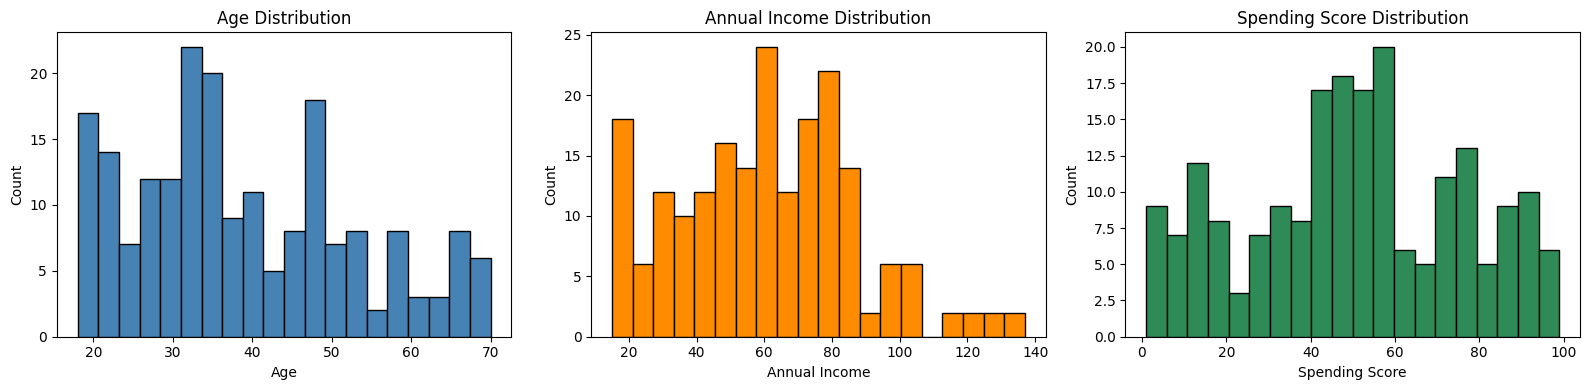

Distribution plots saved.


In [ ]:
# Distribution of Age, Income, and Spending Score
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df[age_col], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

axes[1].hist(df[income_col], bins=20, color='darkorange', edgecolor='black')
axes[1].set_title('Annual Income Distribution')
axes[1].set_xlabel('Annual Income')
axes[1].set_ylabel('Count')

axes[2].hist(df[spending_col], bins=20, color='seagreen', edgecolor='black')
axes[2].set_title('Spending Score Distribution')
axes[2].set_xlabel('Spending Score')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150)
plt.show()
print("Distribution plots saved.")

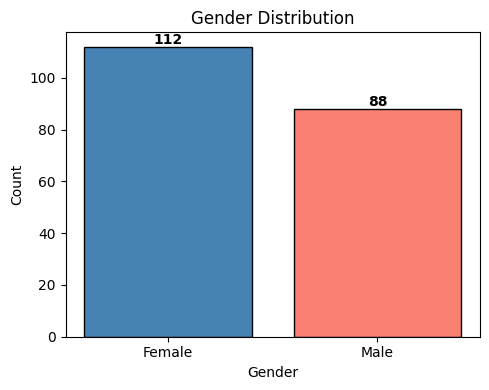

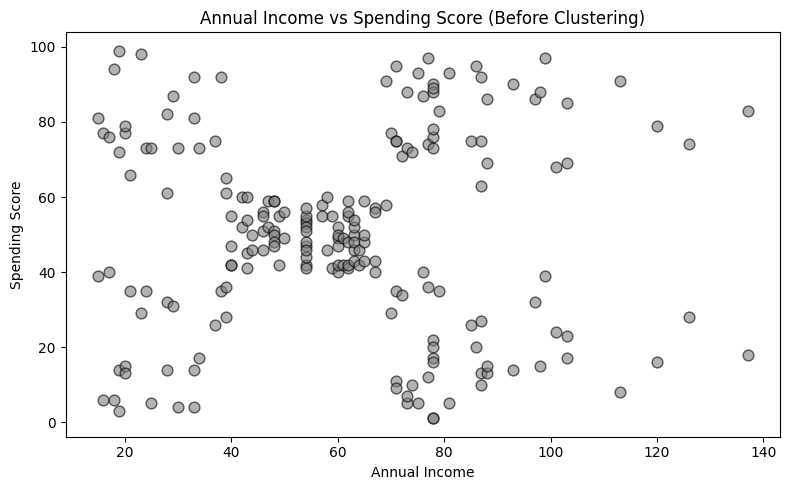

In [ ]:
# Gender distribution (if column exists)
if gender_col:
    fig, ax = plt.subplots(figsize=(5, 4))
    gender_counts = df[gender_col].value_counts()
    ax.bar(gender_counts.index, gender_counts.values, color=['steelblue', 'salmon'], edgecolor='black')
    ax.set_title('Gender Distribution')
    ax.set_xlabel('Gender')
    ax.set_ylabel('Count')
    for i, v in enumerate(gender_counts.values):
        ax.text(i, v + 1, str(v), ha='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig('gender_distribution.png', dpi=150)
    plt.show()

# Scatter plot of Income vs Spending Score (before clustering)
plt.figure(figsize=(8, 5))
plt.scatter(df[income_col], df[spending_col], color='gray', alpha=0.6, edgecolors='black', s=60)
plt.title('Annual Income vs Spending Score (Before Clustering)')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.tight_layout()
plt.savefig('scatter_before_clustering.png', dpi=150)
plt.show()

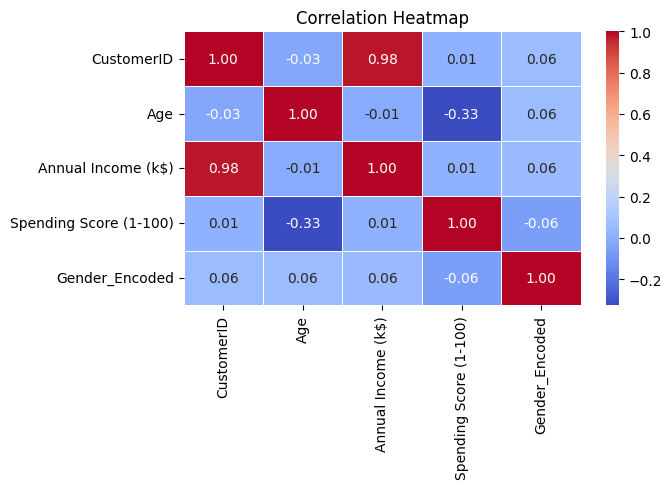

In [ ]:
# Correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(7, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

## Step 6 - Finding the Optimal Number of Clusters (Elbow Method)

In [ ]:
# Calculate WCSS for K = 1 to 10
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    print(f"K = {k}  |  WCSS = {kmeans.inertia_:.2f}")

print("\nWCSS values calculated for K = 1 to 10.")

K = 1  |  WCSS = 400.00
K = 2  |  WCSS = 269.69
K = 3  |  WCSS = 157.70
K = 4  |  WCSS = 108.92
K = 5  |  WCSS = 65.57
K = 6  |  WCSS = 55.06
K = 7  |  WCSS = 44.86
K = 8  |  WCSS = 37.23
K = 9  |  WCSS = 32.39
K = 10  |  WCSS = 29.98

WCSS values calculated for K = 1 to 10.


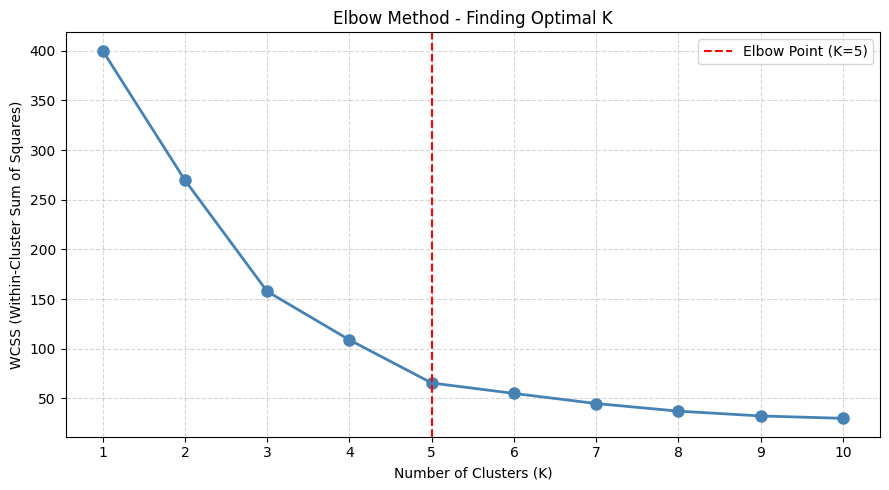

Elbow plot saved. The curve bends around K=5, making it the optimal number of clusters.


In [ ]:
# Plot the Elbow Curve
plt.figure(figsize=(9, 5))
plt.plot(k_range, wcss, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='Elbow Point (K=5)')
plt.title('Elbow Method - Finding Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(k_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150)
plt.show()
print("Elbow plot saved. The curve bends around K=5, making it the optimal number of clusters.")

## Step 7 - Apply K-Means Clustering with K


In [ ]:
# Train the final K-Means model with k
optimal_k = 5

kmeans_final = KMeans(
    n_clusters=optimal_k,
    init='k-means++',      # Smarter centroid initialization
    max_iter=300,           # Maximum iterations before stopping
    n_init=10,              # Run algorithm 10 times, pick best result
    random_state=42
)

kmeans_final.fit(X_scaled)

# Assign cluster labels back to the original dataframe
df['Cluster'] = kmeans_final.labels_

print("K-Means model trained successfully.")
print(f"\nNumber of customers in each cluster:")
print(df['Cluster'].value_counts().sort_index())

K-Means model trained successfully.

Number of customers in each cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [ ]:
# Silhouette Score - measures how well clusters are separated (higher is better, max = 1)
sil_score = silhouette_score(X_scaled, kmeans_final.labels_)
print(f"Silhouette Score for K=5: {sil_score:.4f}")
print("(A score closer to 1 means clusters are well-separated and distinct.)")

Silhouette Score for K=5: 0.5547
(A score closer to 1 means clusters are well-separated and distinct.)


## Step 8 - Visualize the Clusters

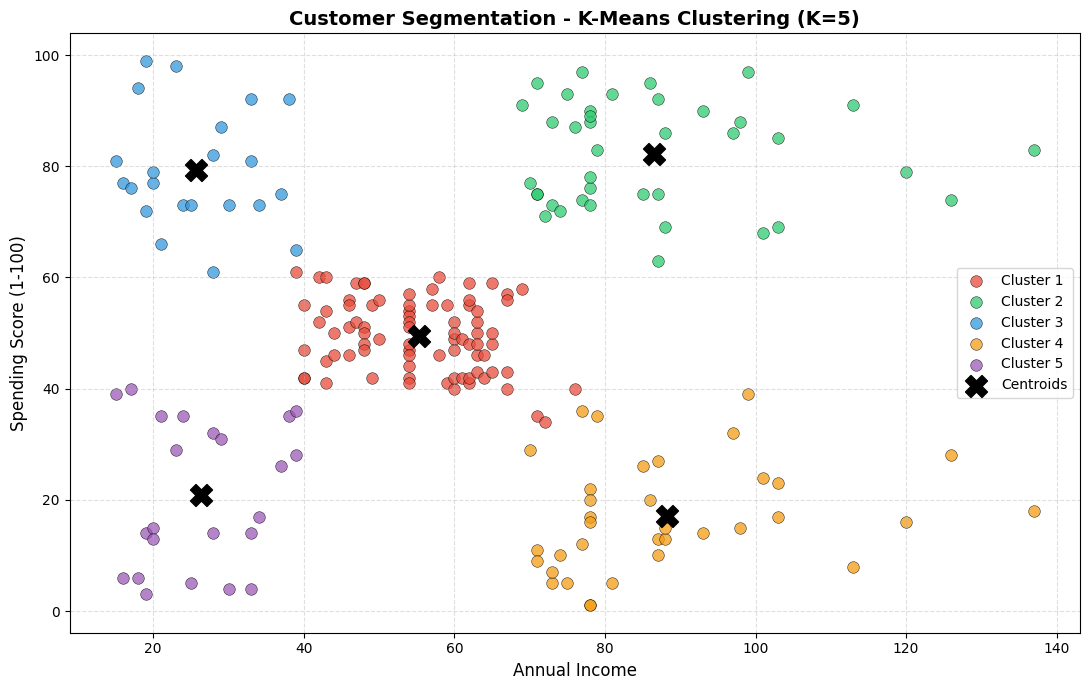

Cluster visualization saved.


In [ ]:
# Define cluster colors and labels
colors = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12', '#9B59B6']
cluster_labels = {
    0: 'Cluster 1',
    1: 'Cluster 2',
    2: 'Cluster 3',
    3: 'Cluster 4',
    4: 'Cluster 5'
}

# Get centroids in original scale
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

# Main cluster plot
plt.figure(figsize=(11, 7))

for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(
        cluster_data[income_col],
        cluster_data[spending_col],
        s=70,
        color=colors[i],
        alpha=0.75,
        edgecolors='black',
        linewidths=0.4,
        label=cluster_labels[i]
    )

# Plot centroids
plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    s=250,
    color='black',
    marker='X',
    zorder=5,
    label='Centroids'
)

plt.title('Customer Segmentation - K-Means Clustering (K=5)', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150)
plt.show()
print("Cluster visualization saved.")

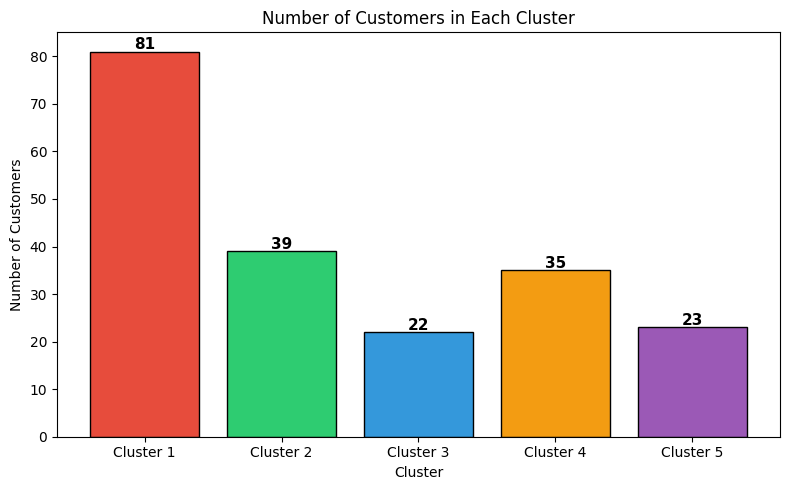

In [ ]:
# Cluster size bar chart
cluster_counts = df['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(
    [f'Cluster {i+1}' for i in range(optimal_k)],
    cluster_counts.values,
    color=colors,
    edgecolor='black'
)
for bar, val in zip(bars, cluster_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val),
             ha='center', fontweight='bold', fontsize=11)
plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('cluster_sizes.png', dpi=150)
plt.show()

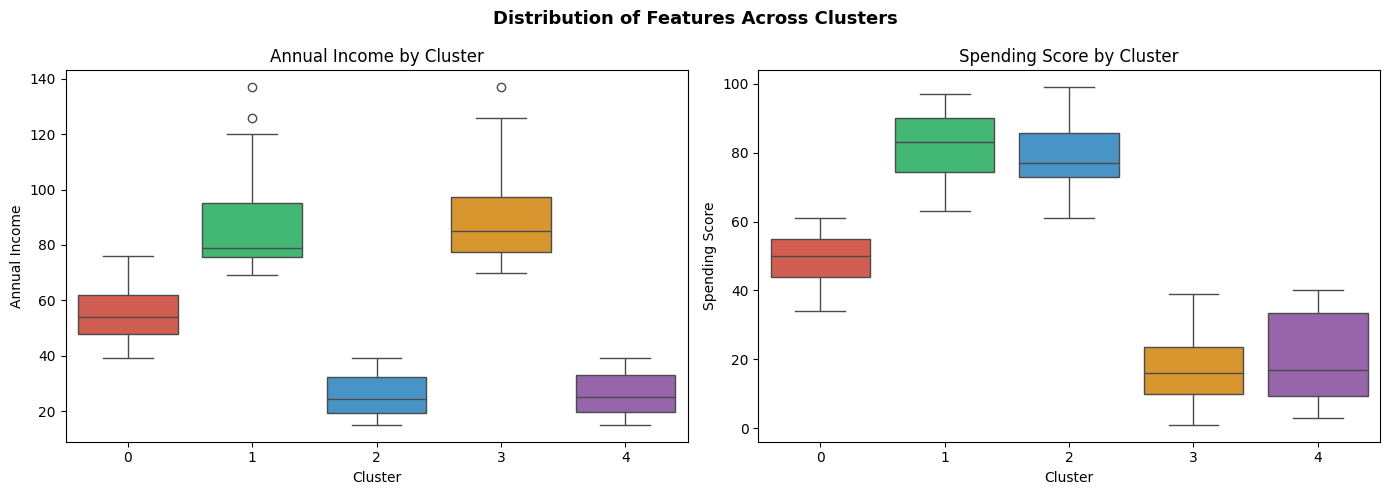

In [ ]:
# Boxplots: Income and Spending Score per Cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Cluster', y=income_col, palette=colors, ax=axes[0])
axes[0].set_title('Annual Income by Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Annual Income')

sns.boxplot(data=df, x='Cluster', y=spending_col, palette=colors, ax=axes[1])
axes[1].set_title('Spending Score by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Spending Score')

plt.suptitle('Distribution of Features Across Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_boxplots.png', dpi=150)
plt.show()

## Step 9 - Cluster Analysis and Business Interpretation

In [ ]:
# Compute mean values per cluster
cluster_summary = df.groupby('Cluster')[[income_col, spending_col, age_col]].mean().round(2)
cluster_summary.index = [f'Cluster {i}' for i in cluster_summary.index]

print("Cluster Summary - Mean Values:")
print(cluster_summary.to_string())

Cluster Summary - Mean Values:
           Annual Income (k$)  Spending Score (1-100)    Age
Cluster 0               55.30                   49.52  42.72
Cluster 1               86.54                   82.13  32.69
Cluster 2               25.73                   79.36  25.27
Cluster 3               88.20                   17.11  41.11
Cluster 4               26.30                   20.91  45.22


In [ ]:
# Assign human-readable business labels based on Income and Spending
# These are determined by looking at the cluster means
# Get mean income and spending per cluster
means = df.groupby('Cluster')[[income_col, spending_col]].mean()
overall_income_mean = df[income_col].mean()
overall_spending_mean = df[spending_col].mean()

business_labels = {}

for cluster_id, row in means.iterrows():
    inc = row[income_col]
    spd = row[spending_col]

    if inc >= overall_income_mean and spd >= overall_spending_mean:
        label = 'Premium Customers (High Income, High Spending)'
    elif inc >= overall_income_mean and spd < overall_spending_mean:
        label = 'Careful Spenders (High Income, Low Spending)'
    elif inc < overall_income_mean and spd >= overall_spending_mean:
        label = 'Impulsive Buyers (Low Income, High Spending)'
    elif inc < overall_income_mean and spd < overall_spending_mean:
        label = 'Budget Customers (Low Income, Low Spending)'
    else:
        label = 'Average Customers (Moderate Income and Spending)'

    business_labels[cluster_id] = label

df['Customer_Segment'] = df['Cluster'].map(business_labels)

print("Business Segment Labels per Cluster:")
for k, v in business_labels.items():
    print(f"  Cluster {k}: {v}")

Business Segment Labels per Cluster:
  Cluster 0: Budget Customers (Low Income, Low Spending)
  Cluster 1: Premium Customers (High Income, High Spending)
  Cluster 2: Impulsive Buyers (Low Income, High Spending)
  Cluster 3: Careful Spenders (High Income, Low Spending)
  Cluster 4: Budget Customers (Low Income, Low Spending)


In [ ]:
# Full cluster summary with business labels
full_summary = df.groupby('Customer_Segment')[[income_col, spending_col, age_col]].agg(['mean', 'count']).round(2)
print("Full Business Segment Summary:")
print(full_summary.to_string())

Full Business Segment Summary:
                                               Annual Income (k$)       Spending Score (1-100)          Age      
                                                             mean count                   mean count   mean count
Customer_Segment                                                                                                 
Budget Customers (Low Income, Low Spending)                 48.88   104                  43.19   104  43.27   104
Careful Spenders (High Income, Low Spending)                88.20    35                  17.11    35  41.11    35
Impulsive Buyers (Low Income, High Spending)                25.73    22                  79.36    22  25.27    22
Premium Customers (High Income, High Spending)              86.54    39                  82.13    39  32.69    39


In [ ]:
# Print actionable marketing strategies for each segment
strategies = {
    'Premium Customers (High Income, High Spending)':
        'Target with loyalty programs, exclusive memberships, and premium product lines. These are your best customers.',
    'Careful Spenders (High Income, Low Spending)':
        'Send personalized discount offers and product recommendations. They have money but need the right trigger to spend.',
    'Impulsive Buyers (Low Income, High Spending)':
        'Promote budget-friendly deals, flash sales, and buy-now-pay-later options. They enjoy spending despite lower income.',
    'Budget Customers (Low Income, Low Spending)':
        'Focus on value-for-money messaging. Offer affordable bundles and necessities rather than premium items.',
    'Average Customers (Moderate Income and Spending)':
        'General engagement through newsletters, seasonal promotions, and mid-range product recommendations.'
}

print("\nMarketing Strategies by Segment\n" + "-"*50)
for segment, strategy in strategies.items():
    count = df[df['Customer_Segment'] == segment].shape[0]
    print(f"\nSegment : {segment}")
    print(f"Count   : {count} customers")
    print(f"Strategy: {strategy}")


Marketing Strategies by Segment
--------------------------------------------------

Segment : Premium Customers (High Income, High Spending)
Count   : 39 customers
Strategy: Target with loyalty programs, exclusive memberships, and premium product lines. These are your best customers.

Segment : Careful Spenders (High Income, Low Spending)
Count   : 35 customers
Strategy: Send personalized discount offers and product recommendations. They have money but need the right trigger to spend.

Segment : Impulsive Buyers (Low Income, High Spending)
Count   : 22 customers
Strategy: Promote budget-friendly deals, flash sales, and buy-now-pay-later options. They enjoy spending despite lower income.

Segment : Budget Customers (Low Income, Low Spending)
Count   : 104 customers
Strategy: Focus on value-for-money messaging. Offer affordable bundles and necessities rather than premium items.

Segment : Average Customers (Moderate Income and Spending)
Count   : 0 customers
Strategy: General engagement

## Step 10 - 3-Feature Clustering (Income + Spending + Age)

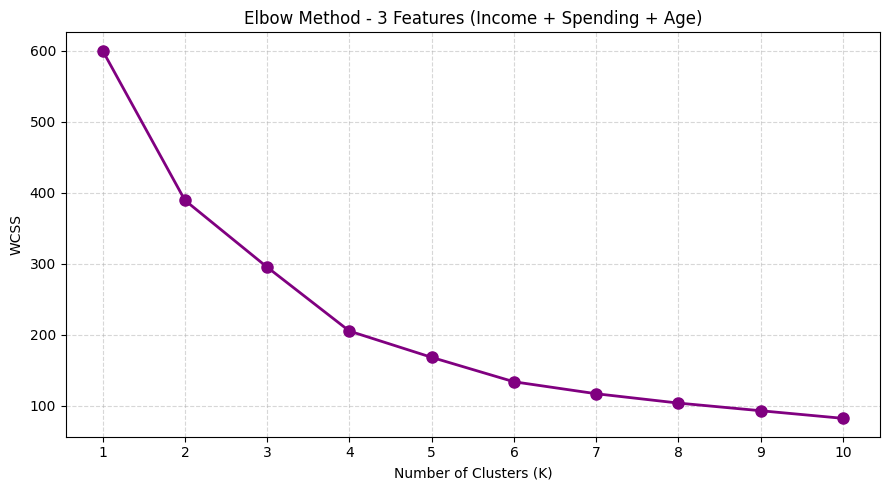

In [ ]:
# Extended clustering using 3 features
X3 = df[[income_col, spending_col, age_col]].copy()
X3_scaled = scaler.fit_transform(X3)

# Find optimal K for 3-feature model
wcss3 = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    km.fit(X3_scaled)
    wcss3.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss3, marker='o', color='purple', linewidth=2, markersize=8)
plt.title('Elbow Method - 3 Features (Income + Spending + Age)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('elbow_3features.png', dpi=150)
plt.show()

Silhouette Score (3-Feature Model, K=6): 0.4284


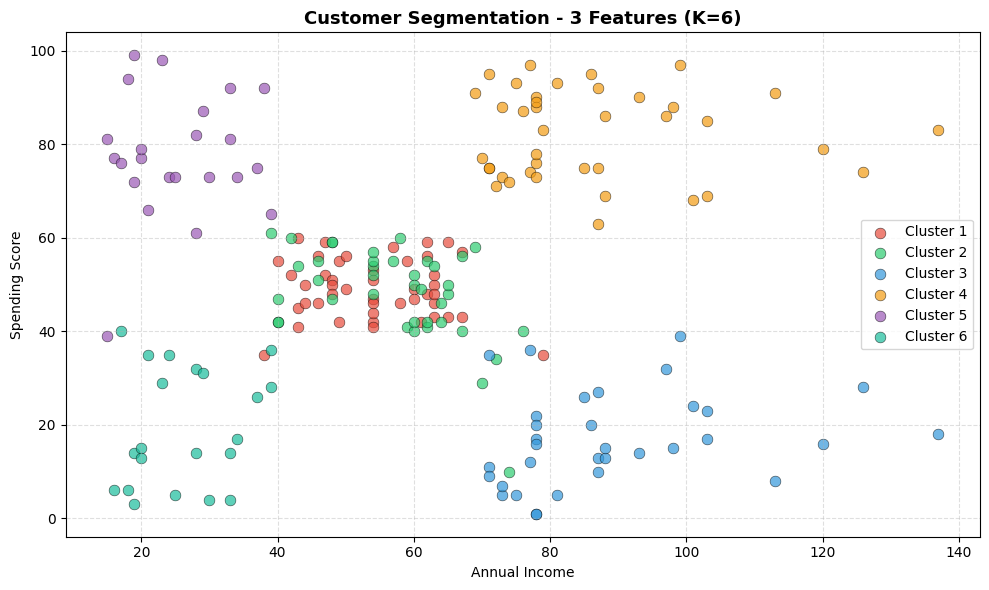

In [ ]:
# Train 3-feature model with K=6 (common optimal for 3-feature mall dataset)
kmeans_3f = KMeans(n_clusters=6, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans_3f.fit(X3_scaled)
df['Cluster_3F'] = kmeans_3f.labels_

sil_3f = silhouette_score(X3_scaled, kmeans_3f.labels_)
print(f"Silhouette Score (3-Feature Model, K=6): {sil_3f:.4f}")

# Visualize Income vs Spending colored by 3F cluster
colors6 = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12', '#9B59B6', '#1ABC9C']
plt.figure(figsize=(10, 6))
for i in range(6):
    subset = df[df['Cluster_3F'] == i]
    plt.scatter(subset[income_col], subset[spending_col],
                s=60, color=colors6[i], alpha=0.7, edgecolors='black',
                linewidths=0.4, label=f'Cluster {i+1}')

plt.title('Customer Segmentation - 3 Features (K=6)', fontsize=13, fontweight='bold')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('clusters_3features.png', dpi=150)
plt.show()

## Step 11 - Save Final Output

In [ ]:
# Save the final dataset with cluster labels
output_file = 'Customer_Segmentation_Results.csv'
df.to_csv(output_file, index=False)
print(f"Results saved to {output_file}")
print(f"Total rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

Results saved to Customer_Segmentation_Results.csv
Total rows: 200
Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Encoded', 'Cluster', 'Customer_Segment', 'Cluster_3F']


In [ ]:
# Download the output CSV to your computer
from google.colab import files
files.download('Customer_Segmentation_Results.csv')
print("File download initiated.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File download initiated.


## Step 12 - Summary and Conclusion

---

### What This Notebook Did

1. Loaded and explored the Mall Customers dataset
2. Cleaned and preprocessed the data (encoded gender, scaled features)
3. Used the Elbow Method to find the optimal number of clusters
4. Applied K-Means Clustering with K=5
5. Visualized the resulting customer segments
6. Interpreted each cluster with a business label and marketing strategy
7. Extended the analysis to 3 features (Income + Spending + Age)
8. Exported the final segmented dataset as a CSV

### Key Findings

The K-Means algorithm successfully divided customers into 5 distinct segments based on their Annual Income and Spending Score. These segments represent meaningfully different customer types that a business can target with tailored marketing strategies.

### What You Can Do Next

- Try DBSCAN or Hierarchical Clustering and compare results
- Integrate real-time customer data from a CRM system
- Build a web app that predicts the segment of a new customer